# Cleopatra ocean styles on **real** data

The cmocean-derived ocean `DATA_STYLES`. The **depth** styles are shown on a real global relief field —
**ETOPO5 bathymetry** over the North Atlantic & Europe (ocean depth + land elevation), fetched from the
PacIOOS ERDDAP. The remaining ocean variables (SST, salinity, chlorophyll, currents, …) each want their own
gridded field; those aren't bundled here, so they're shown as their **colormaps** (the honest thing — colours,
not stand-in data).

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
import cleopatra
from cleopatra.array_glyph import ArrayGlyph
from cleopatra.colors import resolve_single_layer_style
print("cleopatra", cleopatra.__version__)

DATA = Path("../../../examples/data")
z = np.load(DATA / "etopo5_natlantic.npz")
elev = z["elevation"].astype(float)[::-1]      # fixture is lat-ascending -> flip to north-up
# metres: <0 ocean depth, >0 land
extent = [float(v) for v in z["extent"]]
depth = np.where(elev < 0, elev, np.nan)       # ocean-only depths
print("ETOPO5:", elev.shape, "elevation", (round(np.nanmin(elev)), round(np.nanmax(elev))), "m")

cleopatra 0.28.0
ETOPO5: (433, 865) elevation (-6369, 3902) m


## Depth styles on real ETOPO5 bathymetry

`topography` colours land and sea together; `bathymetry` colours ocean depth only. Both are the real relief
field.

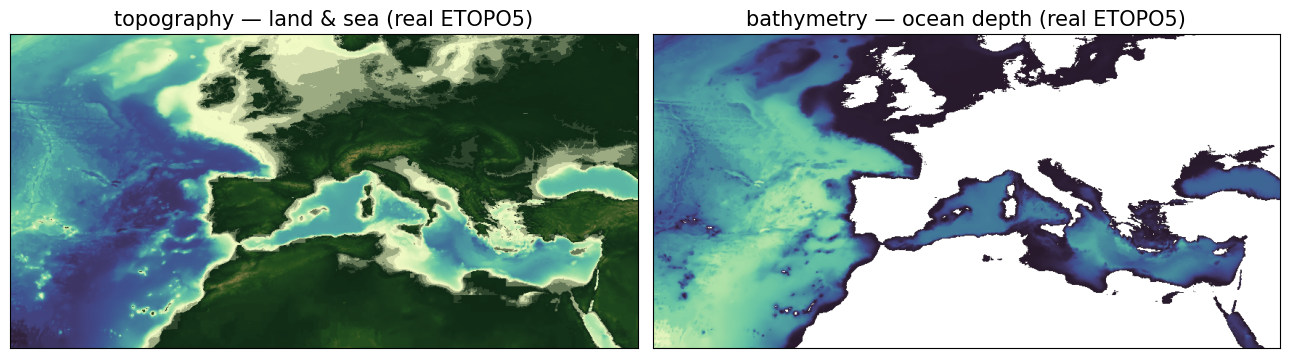

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
gext = [extent[0], extent[2], extent[1], extent[3]]   # [xmin, ymin, xmax, ymax]
ArrayGlyph(elev, extent=gext, ax=axes[0]).plot(style="topography", add_colorbar=False,
                                               title="topography — land & sea (real ETOPO5)")
ArrayGlyph(depth, extent=gext, ax=axes[1]).plot(style="bathymetry", add_colorbar=False,
                                                title="bathymetry — ocean depth (real ETOPO5)")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

## All ocean style colormaps

Every ocean `DATA_STYLES` preset's colormap, as a swatch. Apply any of them to your own gridded variable with
`ArrayGlyph(field, extent=..., ax=ax).plot(style="salinity", ...)`.

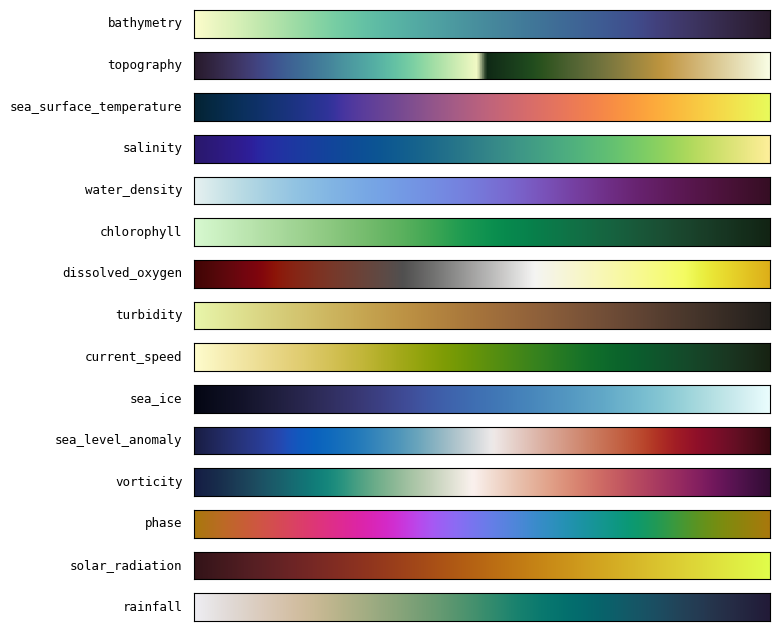

In [3]:
ocean = ["bathymetry", "topography", "sea_surface_temperature", "salinity", "water_density",
         "chlorophyll", "dissolved_oxygen", "turbidity", "current_speed", "sea_ice",
         "sea_level_anomaly", "vorticity", "phase", "solar_radiation", "rainfall"]
def style_cmap(style):
    _, cfg = resolve_single_layer_style(style)
    c = cfg["cmap"]
    return c if hasattr(c, "N") else mpl.colormaps[c]
grad = np.linspace(0, 1, 256).reshape(1, -1)
fig, axes = plt.subplots(len(ocean), 1, figsize=(8, 0.42 * len(ocean)))
fig.subplots_adjust(left=0.26, right=0.98, top=0.99, bottom=0.02, hspace=0.5)
for ax, style in zip(axes, ocean):
    ax.imshow(grad, aspect="auto", cmap=style_cmap(style))
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(-0.02, 0.5, style, transform=ax.transAxes, ha="right", va="center",
            family="monospace", fontsize=9)
plt.show()